# 📊 Análise Exploratória de Dados (EDA) — Telco Customer Churn

Este notebook realiza uma análise exploratória completa do dataset de churn de clientes de telecomunicações, cobrindo:

1. **Visão Geral do Dataset**
2. **Limpeza e Pré-processamento**
3. **Análise Univariada**
4. **Análise Bivariada (relação com Churn)**
5. **Análise de Correlação**
6. **Análise das Razões de Churn**
7. **Principais Insights e Conclusões**


## 1. Importação de Bibliotecas e Carregamento dos Dados

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configurações visuais
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
sns.set_style('whitegrid')
palette_churn = {'Yes': '#e74c3c', 'No': '#2ecc71'}

print("✅ Bibliotecas carregadas com sucesso!")


✅ Bibliotecas carregadas com sucesso!


In [4]:
df = pd.read_excel('../data/Telco_customer_churn.xlsx')
print(f"Dataset carregado: {df.shape[0]} linhas × {df.shape[1]} colunas")
df.head()


Dataset carregado: 7043 linhas × 33 colunas


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


## 2. Visão Geral do Dataset

### 2.1 Estrutura e Tipos de Dados

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [6]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,7043,7043,3668-QPYBK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Count,7043.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
Country,7043,1,United States,7043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,7043,1,California,7043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,7043,1129,Los Angeles,305,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zip Code,7043.0,NaN,NaN,NaN,93521.964646,1865.794555,90001.0,92102.0,93552.0,95351.0,96161.0
Lat Long,7043,1652,"34.159534, -116.425984",5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Latitude,7043.0,NaN,NaN,NaN,36.282441,2.455723,32.555828,34.030915,36.391777,38.224869,41.962127
Longitude,7043.0,NaN,NaN,NaN,-119.79888,2.157889,-124.301372,-121.815412,-119.730885,-118.043237,-114.192901
Gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2.2 Valores Ausentes

In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Ausentes': missing, '% Ausente': missing_pct})
missing_df[missing_df['Ausentes'] > 0]


,Ausentes,% Ausente
Churn Reason,5174,73.46


### 2.3 Valores Únicos por Coluna

In [8]:
unique_info = pd.DataFrame({
    'Tipo': df.dtypes,
    'Únicos': df.nunique(),
    'Exemplo': [df[c].dropna().iloc[0] if len(df[c].dropna()) > 0 else None for c in df.columns]
})
unique_info


,Tipo,Únicos,Exemplo
CustomerID,object,7043,3668-QPYBK
Count,int64,1,1
Country,object,1,United States
State,object,1,California
City,object,1129,Los Angeles
Zip Code,int64,1652,90003
Lat Long,object,1652,"33.964131, -118.272783"
Latitude,float64,1652,33.964131
Longitude,float64,1651,-118.272783
Gender,object,2,Male


## 3. Limpeza e Pré-processamento

Vamos tratar colunas desnecessárias e converter tipos de dados.


In [9]:
# Remover colunas constantes ou redundantes
cols_drop = ['Count', 'Country', 'State', 'Lat Long', 'CustomerID']
df_clean = df.drop(columns=cols_drop)

# Converter Total Charges para numérico
df_clean['Total Charges'] = pd.to_numeric(df_clean['Total Charges'], errors='coerce')
print(f"Valores nulos em Total Charges após conversão: {df_clean['Total Charges'].isnull().sum()}")

# Preencher nulos de Total Charges com 0 (clientes novos com tenure 0)
df_clean['Total Charges'] = df_clean['Total Charges'].fillna(0)

# Criar variável binária de churn
df_clean['Churn'] = (df_clean['Churn Label'] == 'Yes').astype(int)

print(f"\nDataset limpo: {df_clean.shape[0]} linhas × {df_clean.shape[1]} colunas")
df_clean.head()


Valores nulos em Total Charges após conversão: 11

Dataset limpo: 7043 linhas × 29 colunas


,City,Zip Code,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,...,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason,Churn
0,Los Angeles,90003,33.964131,-118.272783,Male,No,No,No,2,Yes,...,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer,1
1,Los Angeles,90005,34.059281,-118.307420,Female,No,No,Yes,2,Yes,...,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved,1
2,Los Angeles,90006,34.048013,-118.293953,Female,No,No,Yes,8,Yes,...,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved,1
3,Los Angeles,90010,34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,...,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved,1
4,Los Angeles,90015,34.039224,-118.266293,Male,No,No,Yes,49,Yes,...,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices,1


## 4. Distribuição da Variável Alvo (Churn)

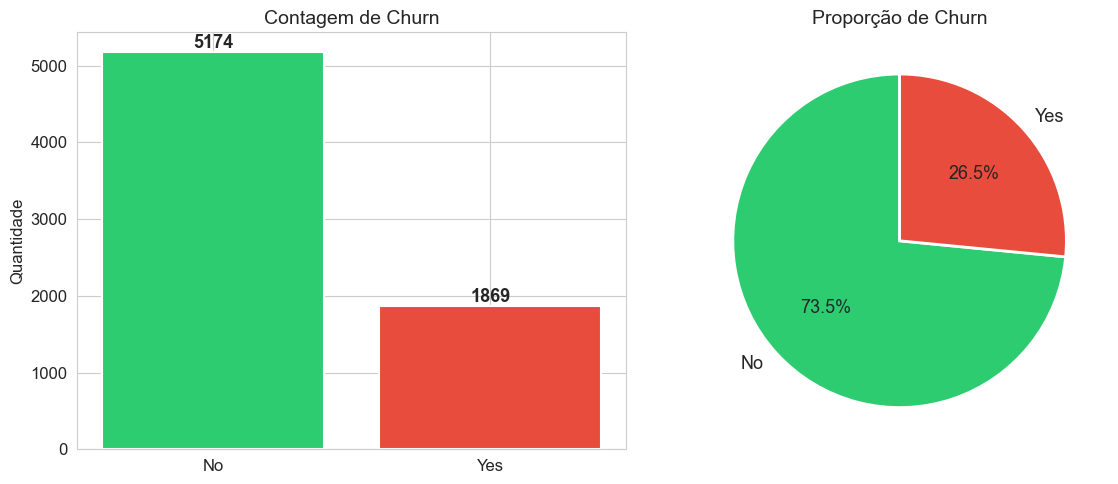

Taxa de churn: 26.5%


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Contagem
churn_counts = df_clean['Churn Label'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(churn_counts.index, churn_counts.values, color=colors, edgecolor='white', linewidth=1.5)
for i, (idx, val) in enumerate(zip(churn_counts.index, churn_counts.values)):
    axes[0].text(i, val + 50, f'{val}', ha='center', fontweight='bold', fontsize=13)
axes[0].set_title('Contagem de Churn')
axes[0].set_ylabel('Quantidade')

# Percentual
axes[1].pie(churn_counts.values, labels=churn_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 13},
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporção de Churn')

plt.tight_layout()
plt.show()

print(f"Taxa de churn: {df_clean['Churn'].mean()*100:.1f}%")


## 5. Análise Univariada

### 5.1 Variáveis Numéricas

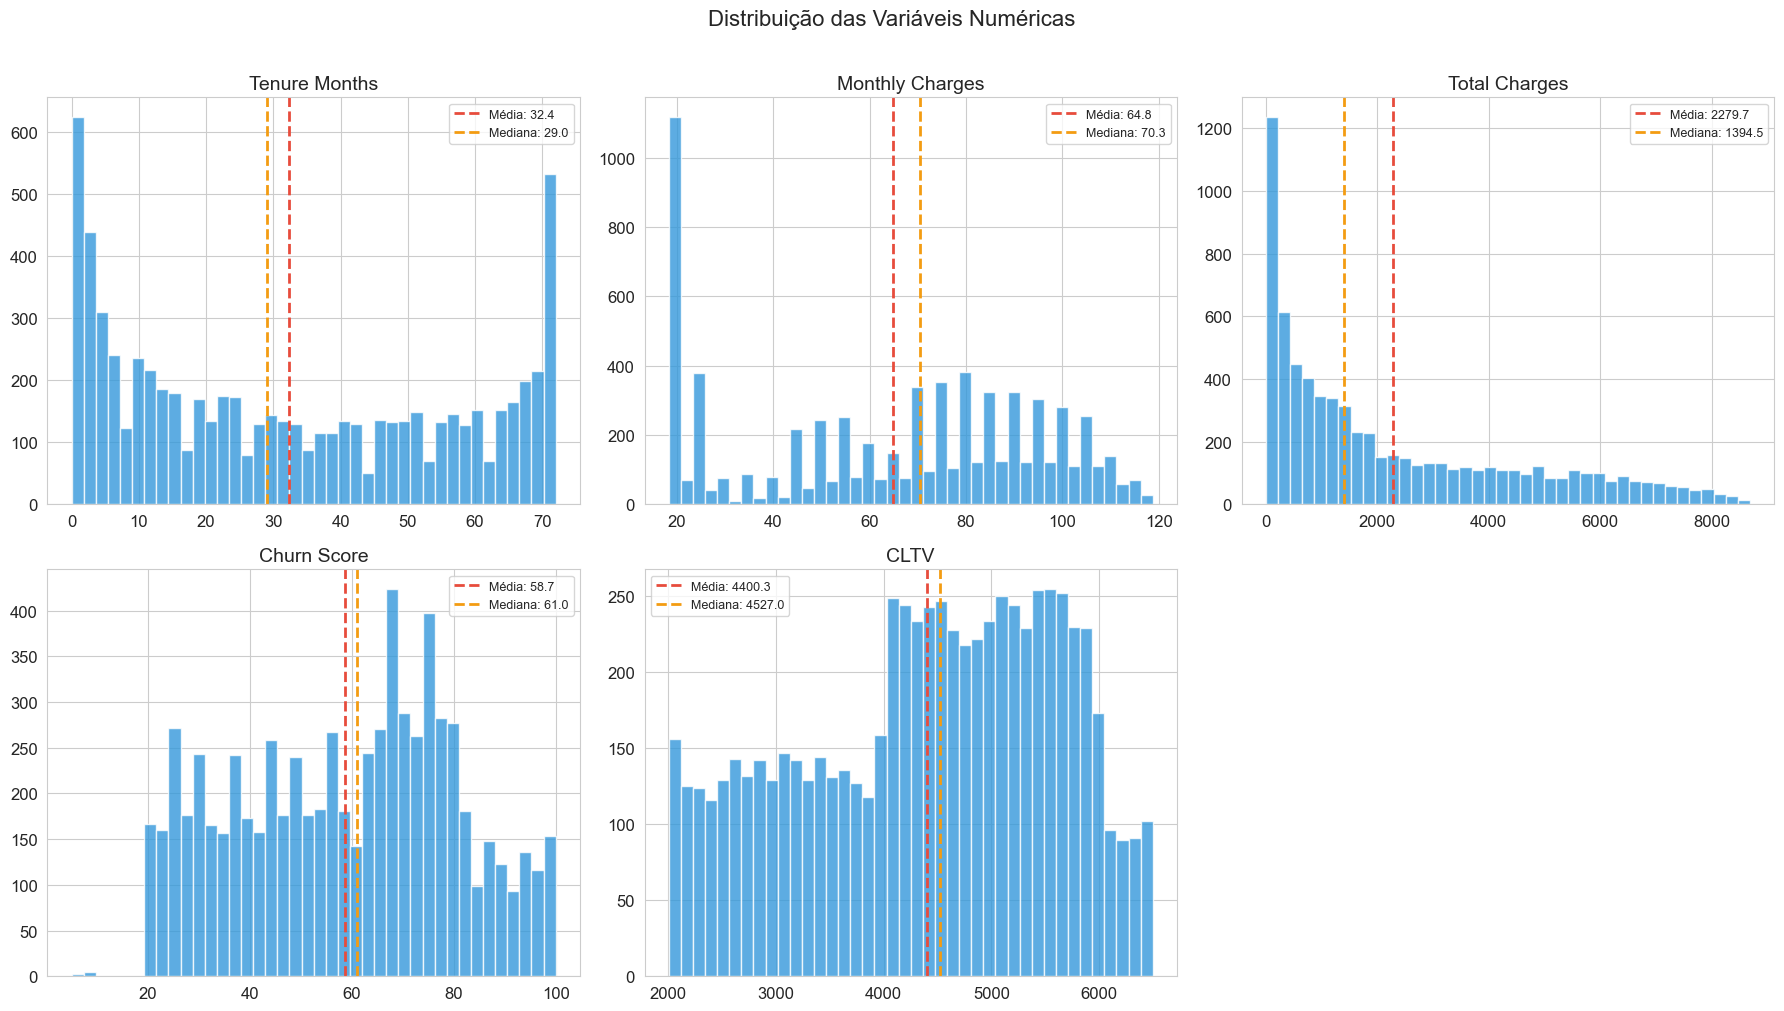

In [11]:
num_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Score', 'CLTV']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df_clean[col], bins=40, color='#3498db', edgecolor='white', alpha=0.8)
    axes[i].axvline(df_clean[col].mean(), color='#e74c3c', linestyle='--', linewidth=2, label=f'Média: {df_clean[col].mean():.1f}')
    axes[i].axvline(df_clean[col].median(), color='#f39c12', linestyle='--', linewidth=2, label=f'Mediana: {df_clean[col].median():.1f}')
    axes[i].set_title(col)
    axes[i].legend(fontsize=9)

axes[-1].axis('off')
plt.suptitle('Distribuição das Variáveis Numéricas', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


In [12]:
# Estatísticas descritivas
df_clean[num_cols].describe().round(2)


,Tenure Months,Monthly Charges,Total Charges,Churn Score,CLTV
count,7043.00,7043.00,7043.00,7043.00,7043.00
mean,32.37,64.76,2279.73,58.70,4400.30
std,24.56,30.09,2266.79,21.53,1183.06
min,0.00,18.25,0.00,5.00,2003.00
25%,9.00,35.50,398.55,40.00,3469.00
50%,29.00,70.35,1394.55,61.00,4527.00
75%,55.00,89.85,3786.60,75.00,5380.50
max,72.00,118.75,8684.80,100.00,6500.00


### 5.2 Variáveis Categóricas

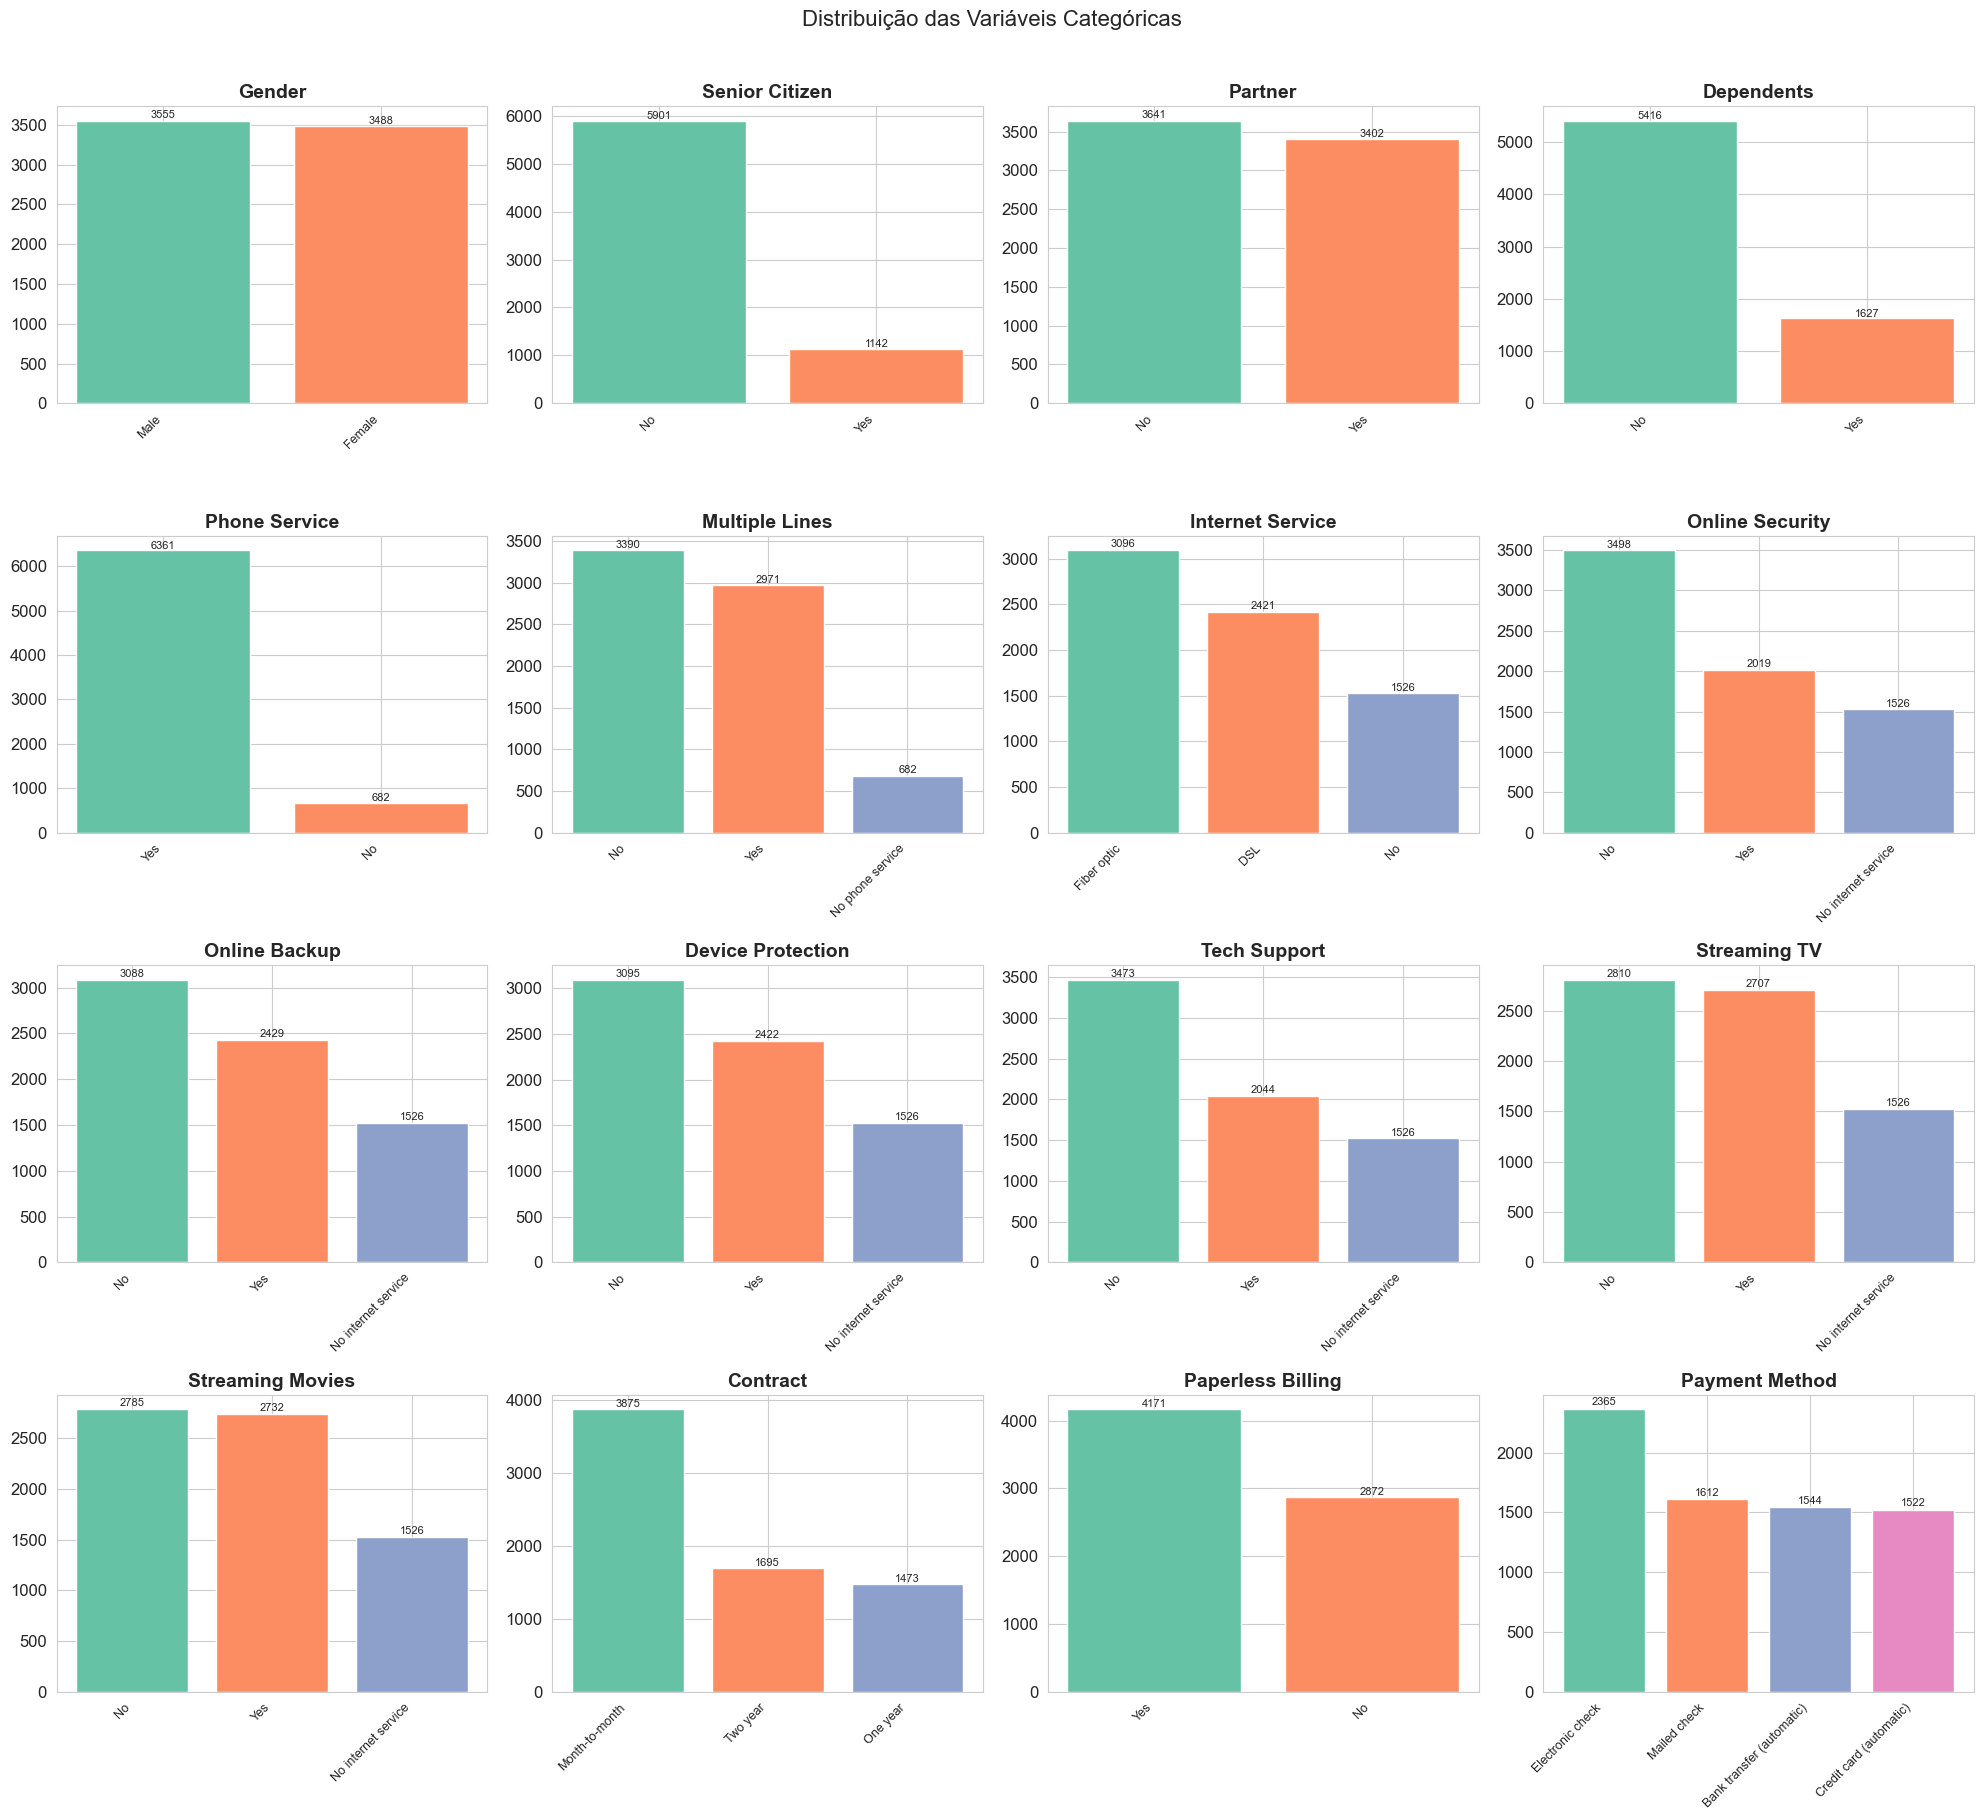

In [13]:
cat_cols = ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
            'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup',
            'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies',
            'Contract', 'Paperless Billing', 'Payment Method']

fig, axes = plt.subplots(4, 4, figsize=(20, 18))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df_clean[col].value_counts()
    bars = axes[i].bar(range(len(counts)), counts.values, color=sns.color_palette('Set2', len(counts)),
                       edgecolor='white', linewidth=1)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xticks(range(len(counts)))
    axes[i].set_xticklabels(counts.index, rotation=45, ha='right', fontsize=9)
    for bar, val in zip(bars, counts.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, val + 30, str(val),
                     ha='center', fontsize=8)

plt.suptitle('Distribuição das Variáveis Categóricas', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


## 6. Análise Bivariada — Relação com Churn

### 6.1 Variáveis Numéricas vs Churn

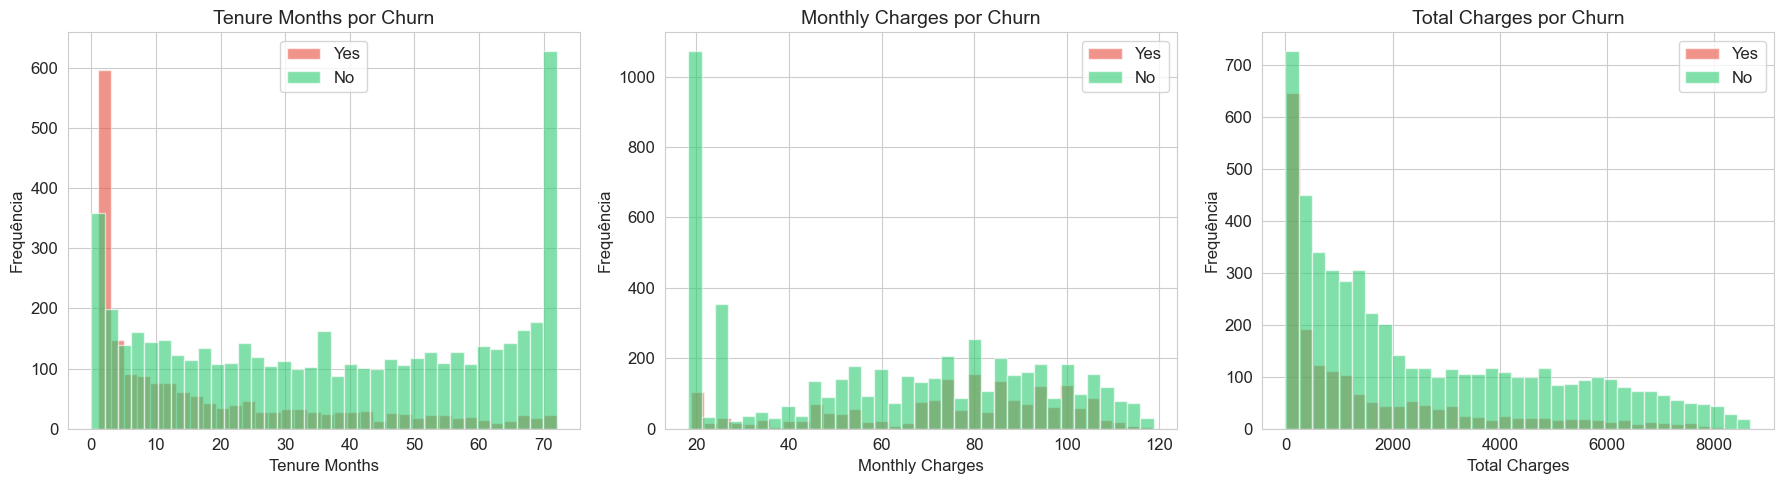

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(['Tenure Months', 'Monthly Charges', 'Total Charges']):
    for label, color in palette_churn.items():
        subset = df_clean[df_clean['Churn Label'] == label][col]
        axes[i].hist(subset, bins=35, alpha=0.6, label=label, color=color, edgecolor='white')
    axes[i].set_title(f'{col} por Churn')
    axes[i].legend()
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequência')

plt.tight_layout()
plt.show()


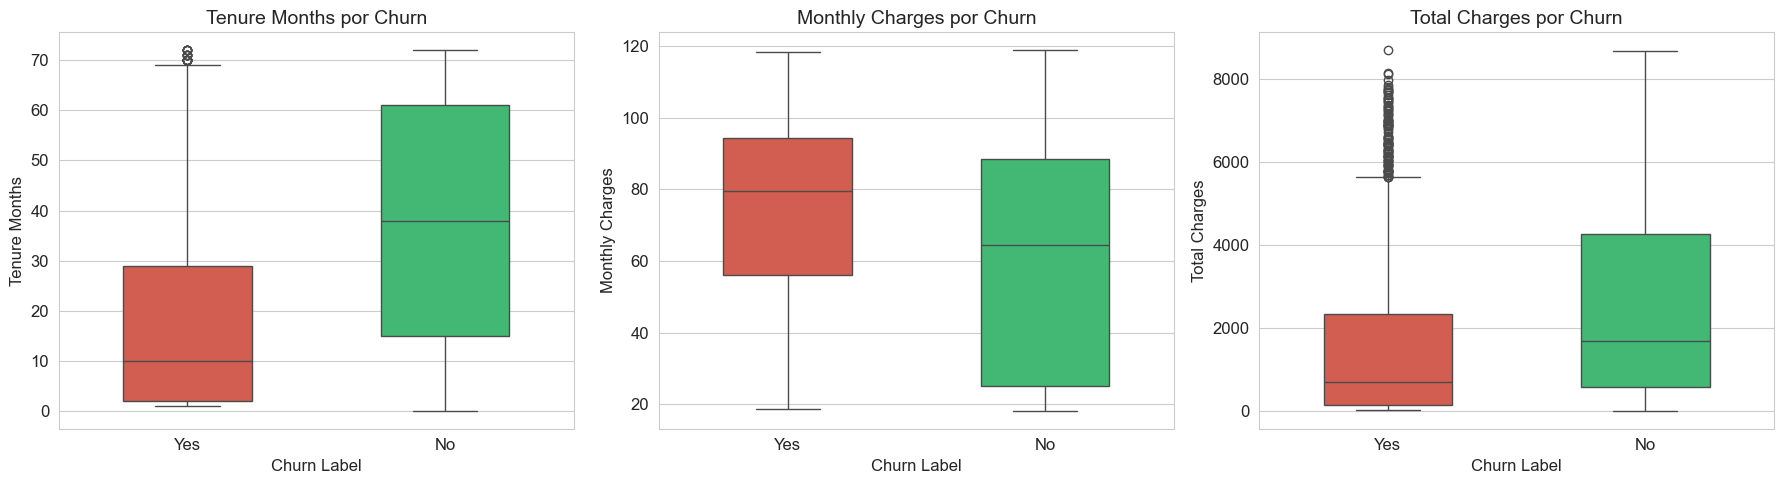

Médias por grupo de Churn:


,Tenure Months,Monthly Charges,Total Charges
Churn Label,,,
No,37.57,61.27,2549.91
Yes,17.98,74.44,1531.80


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(['Tenure Months', 'Monthly Charges', 'Total Charges']):
    sns.boxplot(data=df_clean, x='Churn Label', y=col, ax=axes[i],
                palette=palette_churn, width=0.5)
    axes[i].set_title(f'{col} por Churn')

plt.tight_layout()
plt.show()

# Médias por grupo
print("Médias por grupo de Churn:")
df_clean.groupby('Churn Label')[['Tenure Months', 'Monthly Charges', 'Total Charges']].mean().round(2)


### 6.2 Variáveis Categóricas vs Churn

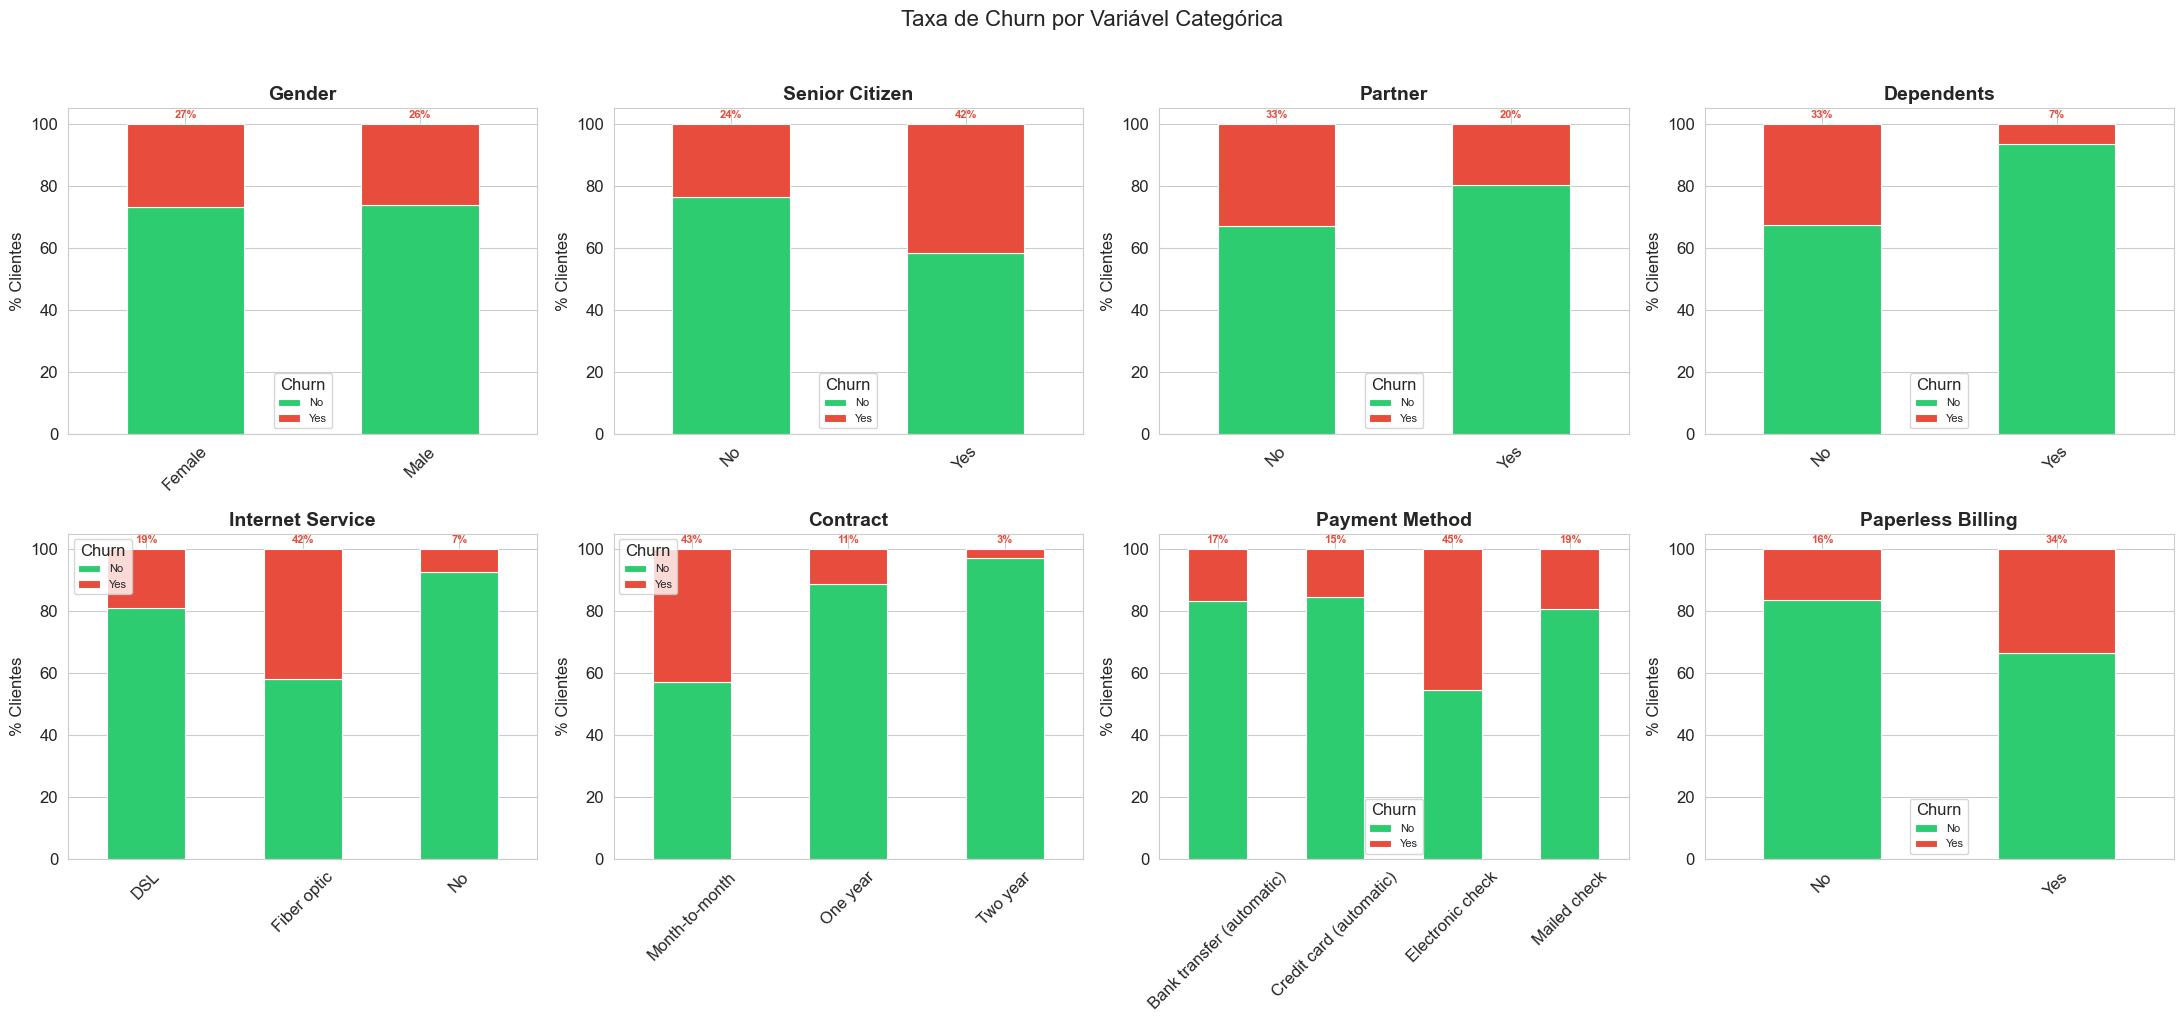

In [16]:
cat_analysis = ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Internet Service',
                'Contract', 'Payment Method', 'Paperless Billing']

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, col in enumerate(cat_analysis):
    ct = pd.crosstab(df_clean[col], df_clean['Churn Label'], normalize='index') * 100
    ct[['No', 'Yes']].plot(kind='bar', stacked=True, ax=axes[i],
                            color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=0.8)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('% Clientes')
    axes[i].set_xlabel('')
    axes[i].legend(title='Churn', fontsize=8)
    axes[i].tick_params(axis='x', rotation=45)
    # Adicionar % de churn acima das barras
    for j, idx in enumerate(ct.index):
        pct = ct.loc[idx, 'Yes']
        axes[i].text(j, 102, f'{pct:.0f}%', ha='center', fontsize=8, color='#e74c3c', fontweight='bold')

plt.suptitle('Taxa de Churn por Variável Categórica', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


### 6.3 Serviços de Internet vs Churn

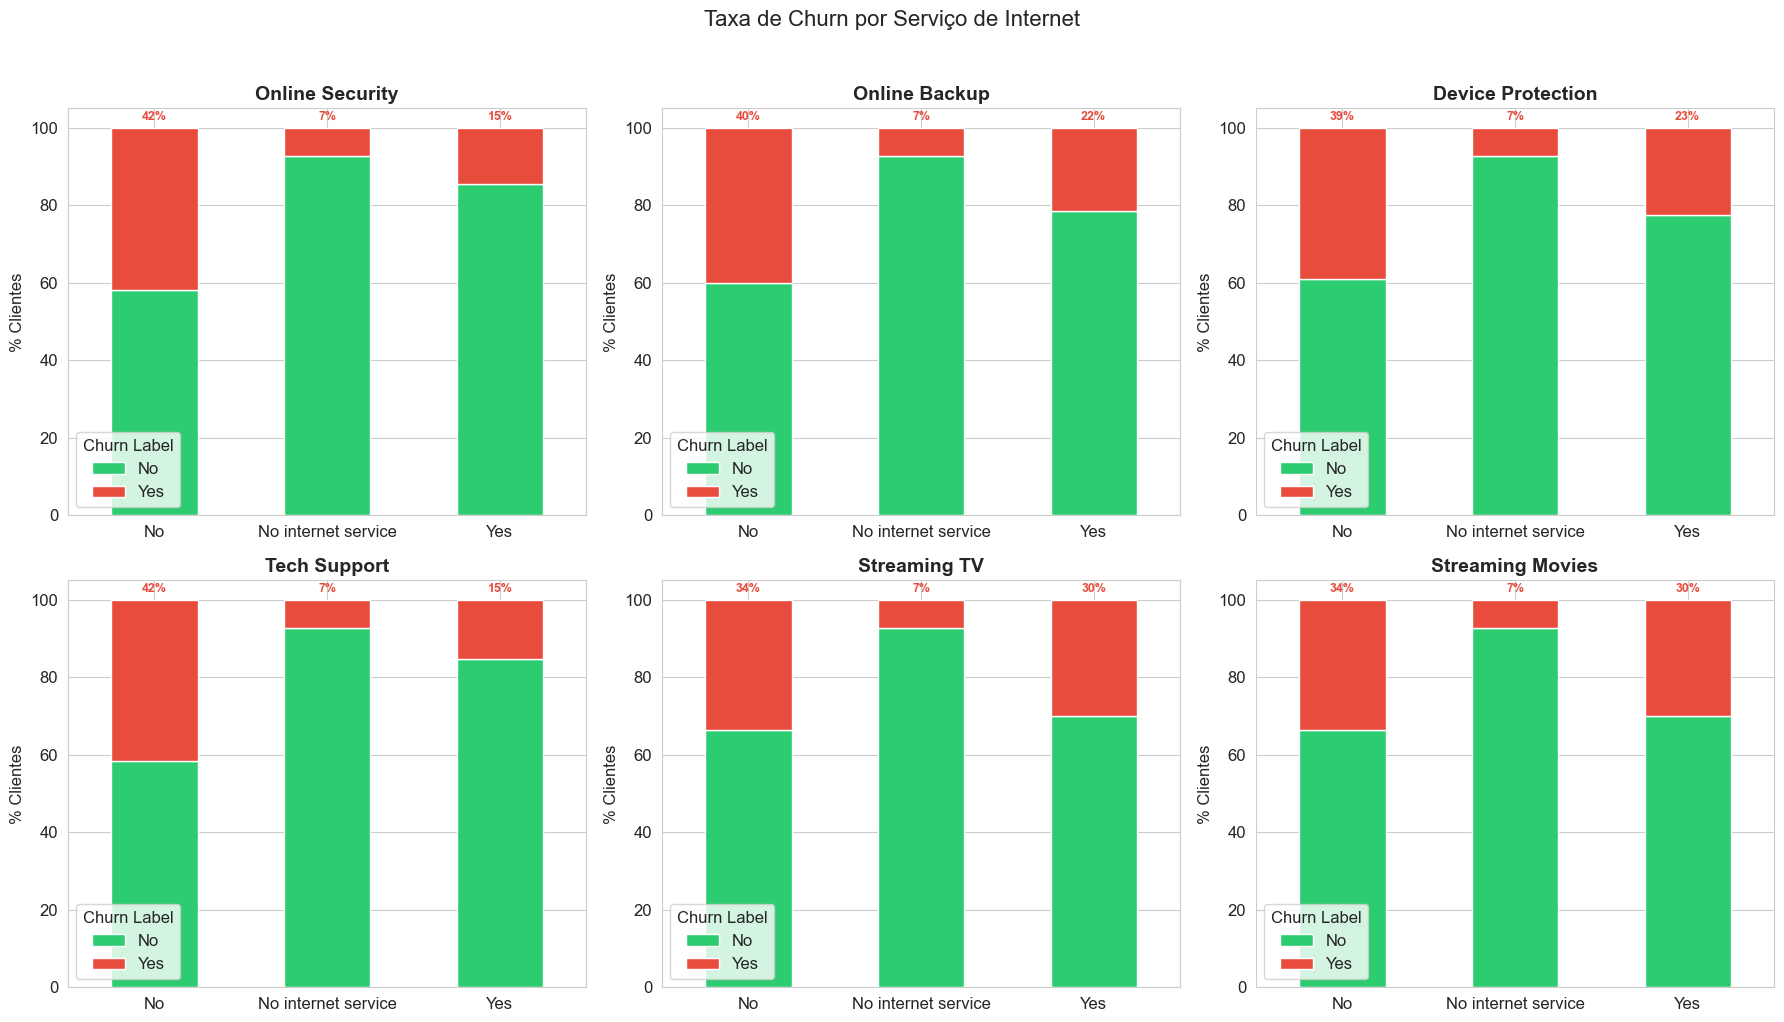

In [17]:
internet_cols = ['Online Security', 'Online Backup', 'Device Protection',
                 'Tech Support', 'Streaming TV', 'Streaming Movies']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(internet_cols):
    ct = pd.crosstab(df_clean[col], df_clean['Churn Label'], normalize='index') * 100
    ct[['No', 'Yes']].plot(kind='bar', stacked=True, ax=axes[i],
                            color=['#2ecc71', '#e74c3c'], edgecolor='white')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('% Clientes')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=0)
    for j, idx in enumerate(ct.index):
        pct = ct.loc[idx, 'Yes']
        axes[i].text(j, 102, f'{pct:.0f}%', ha='center', fontsize=9, color='#e74c3c', fontweight='bold')

plt.suptitle('Taxa de Churn por Serviço de Internet', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


## 7. Análise de Correlação

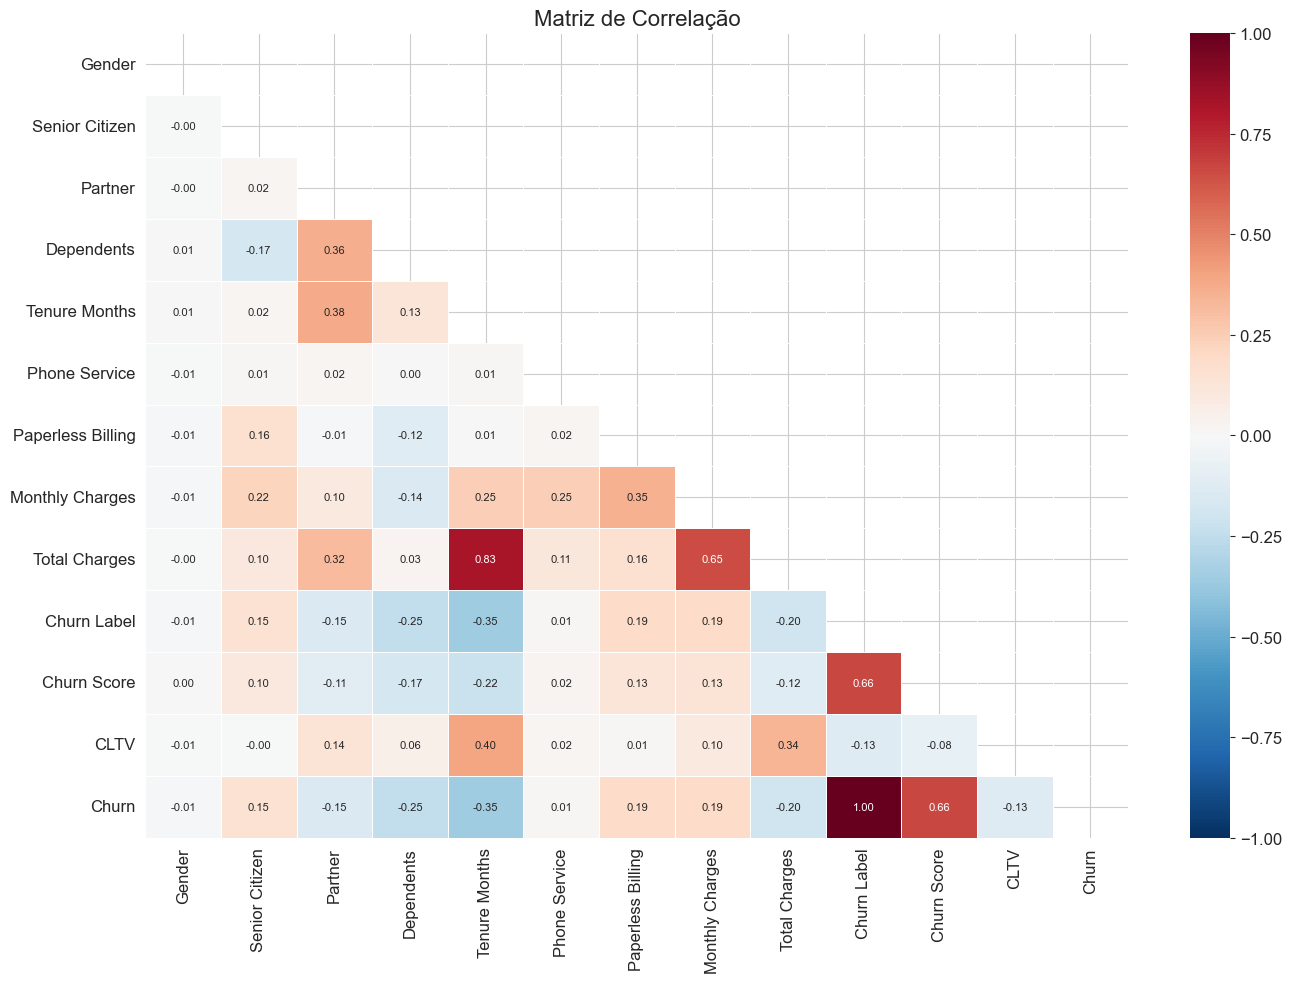

In [18]:
# Codificar variáveis binárias para correlação
df_encoded = df_clean.copy()
binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
for col in df_encoded.select_dtypes(include='object').columns:
    if set(df_encoded[col].dropna().unique()).issubset({'Yes', 'No'}):
        df_encoded[col] = df_encoded[col].map(binary_map)
    elif set(df_encoded[col].dropna().unique()).issubset({'Male', 'Female'}):
        df_encoded[col] = df_encoded[col].map(binary_map)

# Selecionar colunas numéricas para correlação
corr_cols = df_encoded.select_dtypes(include=[np.number]).columns.tolist()
# Remover redundâncias
for c in ['Churn Value', 'Zip Code', 'Latitude', 'Longitude']:
    if c in corr_cols:
        corr_cols.remove(c)

corr_matrix = df_encoded[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5,
            annot_kws={'size': 8})
ax.set_title('Matriz de Correlação', fontsize=16)
plt.tight_layout()
plt.show()


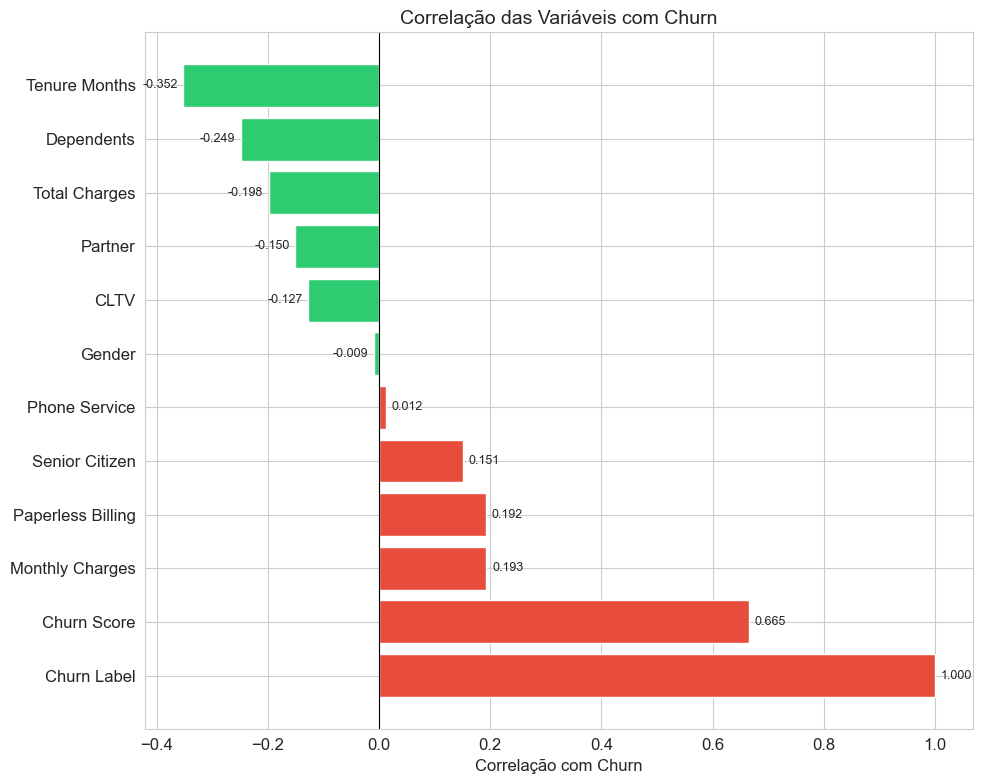

In [19]:
# Top correlações com Churn
if 'Churn' in corr_cols:
    churn_corr = corr_matrix['Churn'].drop('Churn').sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(10, 8))
    colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in churn_corr.values]
    bars = ax.barh(range(len(churn_corr)), churn_corr.values, color=colors, edgecolor='white')
    ax.set_yticks(range(len(churn_corr)))
    ax.set_yticklabels(churn_corr.index)
    ax.set_xlabel('Correlação com Churn')
    ax.set_title('Correlação das Variáveis com Churn', fontsize=14)
    ax.axvline(0, color='black', linewidth=0.8)

    for bar, val in zip(bars, churn_corr.values):
        ax.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

    plt.tight_layout()
    plt.show()


## 8. Análise das Razões de Churn

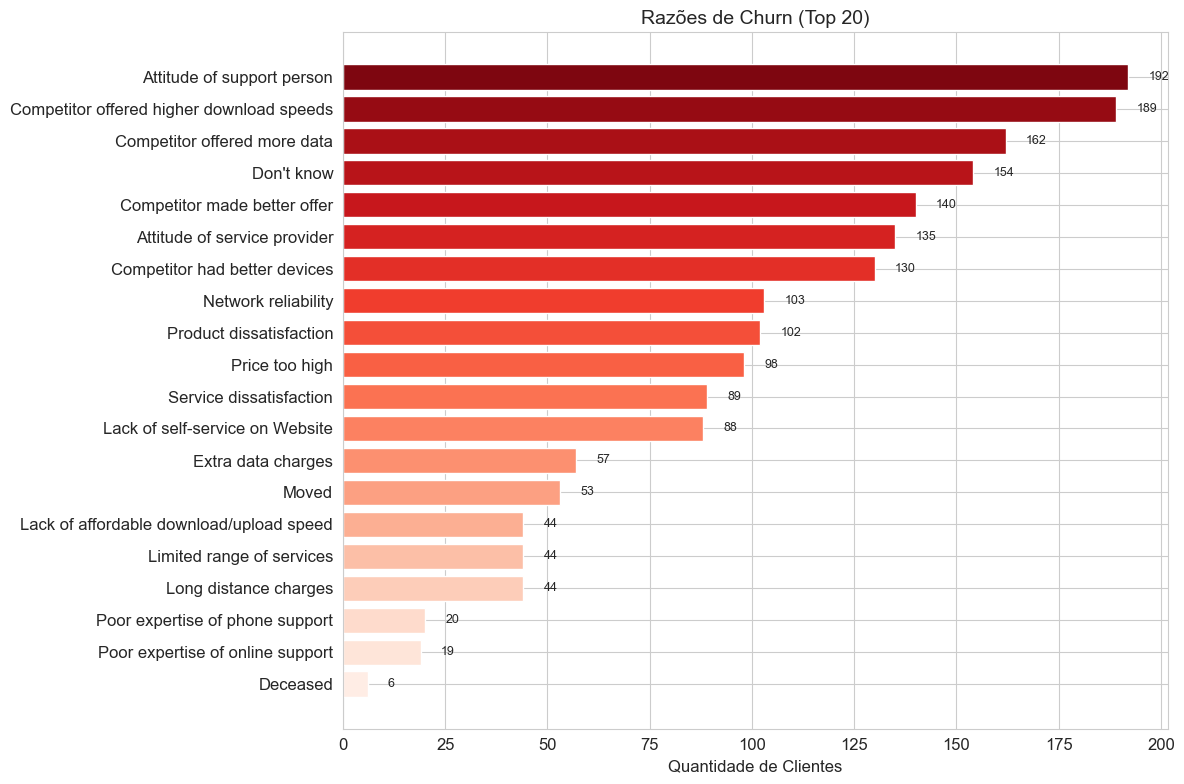


Distribuição por categoria geral:


,Razão,Contagem,% do Total
0,Attitude of support person,192,10.3
1,Competitor offered higher download speeds,189,10.1
2,Competitor offered more data,162,8.7
3,Don't know,154,8.2
4,Competitor made better offer,140,7.5
5,Attitude of service provider,135,7.2
6,Competitor had better devices,130,7.0
7,Network reliability,103,5.5
8,Product dissatisfaction,102,5.5
9,Price too high,98,5.2


In [20]:
churn_reasons = df_clean[df_clean['Churn Label'] == 'Yes']['Churn Reason'].value_counts()

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(range(len(churn_reasons)), churn_reasons.values, color=sns.color_palette('Reds_r', len(churn_reasons)),
               edgecolor='white')
ax.set_yticks(range(len(churn_reasons)))
ax.set_yticklabels(churn_reasons.index)
ax.set_xlabel('Quantidade de Clientes')
ax.set_title('Razões de Churn (Top 20)', fontsize=14)
ax.invert_yaxis()

for bar, val in zip(bars, churn_reasons.values):
    ax.text(val + 5, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Agrupar razões por categoria
print("\nDistribuição por categoria geral:")
reason_cat = churn_reasons.reset_index()
reason_cat.columns = ['Razão', 'Contagem']
reason_cat['% do Total'] = (reason_cat['Contagem'] / reason_cat['Contagem'].sum() * 100).round(1)
reason_cat


## 9. Análise Segmentada

### 9.1 Churn por Tenure (tempo como cliente)

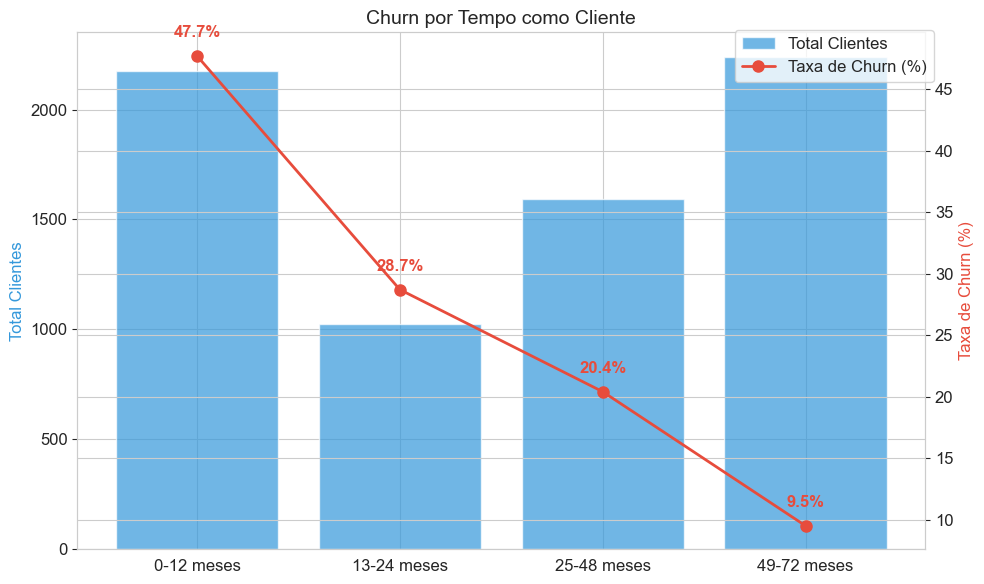

In [21]:
df_clean['Tenure_Group'] = pd.cut(df_clean['Tenure Months'],
                                   bins=[0, 12, 24, 48, 72],
                                   labels=['0-12 meses', '13-24 meses', '25-48 meses', '49-72 meses'])

tenure_churn = df_clean.groupby('Tenure_Group')['Churn'].agg(['mean', 'count']).reset_index()
tenure_churn.columns = ['Grupo', 'Taxa Churn', 'Total Clientes']
tenure_churn['Taxa Churn'] = (tenure_churn['Taxa Churn'] * 100).round(1)

fig, ax1 = plt.subplots(figsize=(10, 6))
x = range(len(tenure_churn))
bars = ax1.bar(x, tenure_churn['Total Clientes'], color='#3498db', alpha=0.7, label='Total Clientes')
ax1.set_ylabel('Total Clientes', color='#3498db')

ax2 = ax1.twinx()
ax2.plot(x, tenure_churn['Taxa Churn'], 'o-', color='#e74c3c', linewidth=2, markersize=8, label='Taxa de Churn (%)')
ax2.set_ylabel('Taxa de Churn (%)', color='#e74c3c')

for i, (bar, rate) in enumerate(zip(bars, tenure_churn['Taxa Churn'])):
    ax2.text(i, rate + 1.5, f'{rate}%', ha='center', fontweight='bold', color='#e74c3c')

ax1.set_xticks(x)
ax1.set_xticklabels(tenure_churn['Grupo'])
ax1.set_title('Churn por Tempo como Cliente', fontsize=14)
fig.legend(loc='upper right', bbox_to_anchor=(0.95, 0.95))
plt.tight_layout()
plt.show()


### 9.2 Churn por Contrato e Método de Pagamento

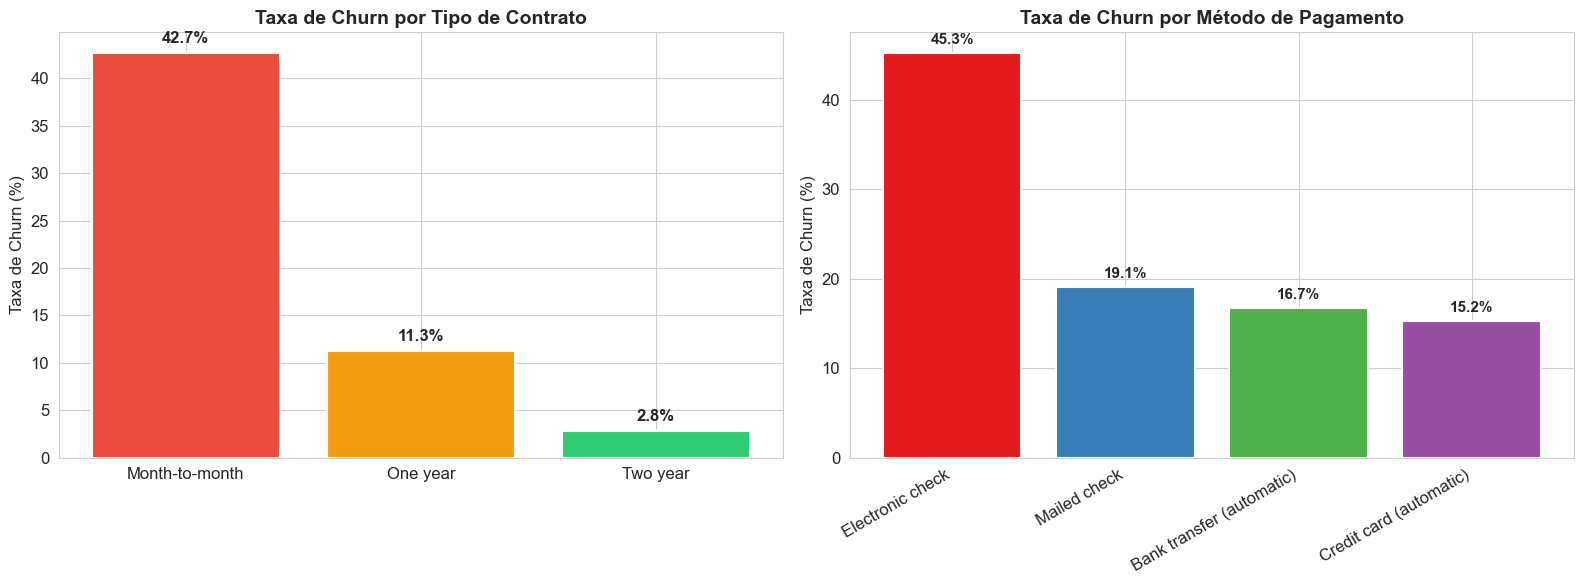

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Contrato
contract_churn = df_clean.groupby('Contract')['Churn'].mean().sort_values(ascending=False) * 100
bars = axes[0].bar(contract_churn.index, contract_churn.values,
                   color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, contract_churn.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 1, f'{val:.1f}%',
                 ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Taxa de Churn por Tipo de Contrato', fontweight='bold')
axes[0].set_ylabel('Taxa de Churn (%)')

# Pagamento
payment_churn = df_clean.groupby('Payment Method')['Churn'].mean().sort_values(ascending=False) * 100
bars = axes[1].bar(range(len(payment_churn)), payment_churn.values,
                   color=sns.color_palette('Set1', len(payment_churn)), edgecolor='white', linewidth=1.5)
axes[1].set_xticks(range(len(payment_churn)))
axes[1].set_xticklabels(payment_churn.index, rotation=30, ha='right')
for bar, val in zip(bars, payment_churn.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 1, f'{val:.1f}%',
                 ha='center', fontweight='bold', fontsize=11)
axes[1].set_title('Taxa de Churn por Método de Pagamento', fontweight='bold')
axes[1].set_ylabel('Taxa de Churn (%)')

plt.tight_layout()
plt.show()


### 9.3 Monthly Charges vs Tenure (colorido por Churn)

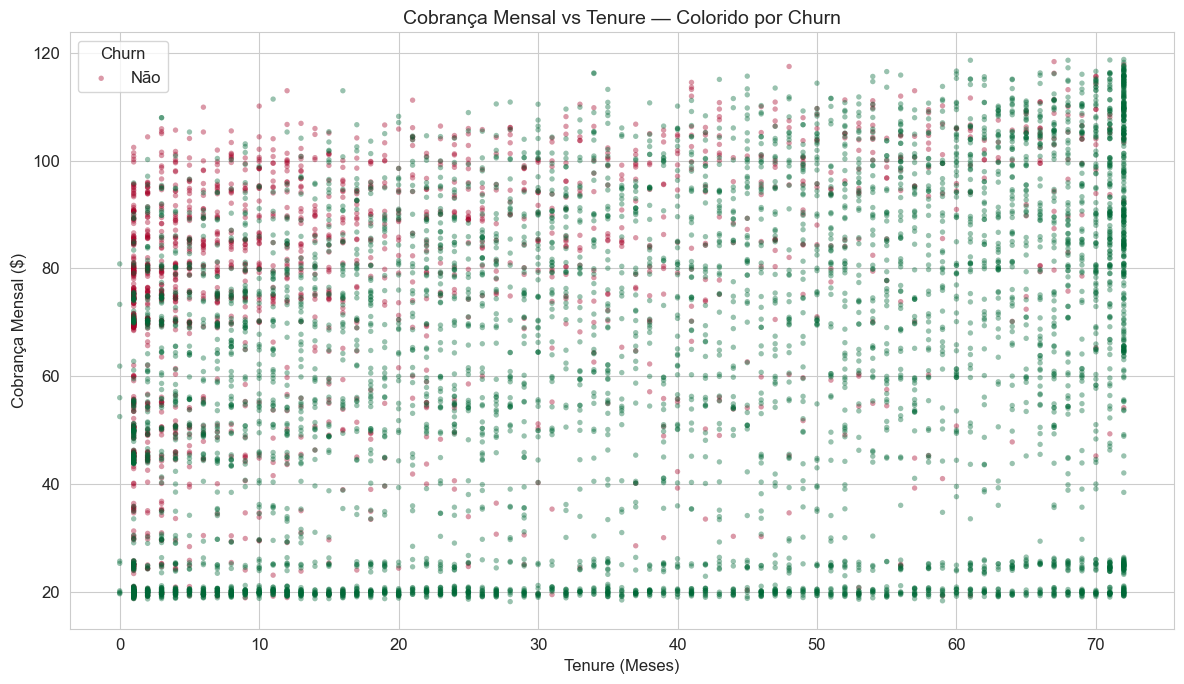

In [23]:
fig, ax = plt.subplots(figsize=(12, 7))
scatter = ax.scatter(df_clean['Tenure Months'], df_clean['Monthly Charges'],
                     c=df_clean['Churn'], cmap='RdYlGn_r', alpha=0.4, s=15, edgecolors='none')
ax.set_xlabel('Tenure (Meses)')
ax.set_ylabel('Cobrança Mensal ($)')
ax.set_title('Cobrança Mensal vs Tenure — Colorido por Churn', fontsize=14)
legend = ax.legend(*scatter.legend_elements(), title='Churn', labels=['Não', 'Sim'])
plt.tight_layout()
plt.show()


## 10. Principais Insights e Conclusões

### Taxa de Churn
- A taxa de churn é de **~26.5%**, indicando que aproximadamente 1 em cada 4 clientes cancela o serviço.

### Perfil do Cliente que dá Churn
- **Contratos mensais**: Clientes com contrato month-to-month têm taxa de churn muito superior (~42%) comparado com contratos anuais (~11%) e bianuais (~3%).
- **Clientes novos**: Quanto menor o tenure, maior a probabilidade de churn. Clientes com 0-12 meses têm a maior taxa.
- **Cobranças mensais altas**: Clientes que dão churn tendem a pagar mais por mês.
- **Pagamento por cheque eletrônico**: Este método de pagamento está associado a taxas de churn significativamente maiores.
- **Sem serviços adicionais**: Clientes sem Online Security, Tech Support, Online Backup ou Device Protection têm maior propensão ao churn.
- **Fiber optic**: Clientes com internet Fiber Optic apresentam maior churn do que DSL ou sem internet.

### Razões de Churn
- As principais razões estão relacionadas a **concorrência** (melhores ofertas/dispositivos) e **atitude do suporte**.
- Isso sugere que estratégias de retenção devem focar em preços competitivos e qualidade do atendimento.

### Recomendações
1. **Incentivar contratos de longo prazo** com descontos progressivos
2. **Programa de onboarding** para os primeiros 12 meses (período crítico)
3. **Bundling de serviços** (segurança, backup, suporte) a preços acessíveis
4. **Melhorar o suporte técnico** — razão frequente de churn
5. **Monitorar clientes com Churn Score alto** para ações proativas de retenção


# 11. Planejamento de Machine Learning (ML Canvas)

Esta seção atende aos requisitos de Ciclo de Vida e Definição de Stakeholders.

| Quadrante | Detalhes do Projeto Telco Churn |
| :--- | :--- |
| **Stakeholders** | Equipe de Retenção (CRM), Marketing e Direção Financeira. |
| **Proposta de Valor** | Reduzir a evasão de clientes através da identificação precoce de comportamentos de risco. |
| **Métricas de Negócio** | Redução na Taxa de Churn (%) e Impacto Financeiro (Churn Evitado). |
| **Métricas Técnicas** | F1-Score (primária), AUC-ROC e PR-AUC. |
| **SLOs (Serviço)** | Predição em batch (semanal); Disponibilidade do pipeline de 99.5%. |
| **Tarefa de ML** | Classificação Binária (Churn: Sim/Não). |

# 12. Definição de Métricas de Sucesso

Foco: formulação do problema e conexão com o negócio.

### 12.1 Métricas Técnicas
* **F1-Score:** Escolhida como métrica principal devido ao desequilíbrio de classes (apenas 26% de churn), garantindo um equilíbrio entre Precisão e Recall.
* **AUC-ROC e PR-AUC:** Utilizadas para medir a capacidade do modelo em distinguir as classes em diferentes limiares, sendo a PR-AUC mais rigorosa para a classe positiva (Churn).

### 12.2 Métrica de Negócio: Custo de Churn Evitado
O sucesso financeiro será calculado com base no valor recuperado:
**ROI Estimado = (Clientes_Retidos * CLTV_Médio) - Custo_da_Ação**

* Conforme nossa EDA, o CLTV médio é de **$4.400**.
* Se o modelo identificar corretamente 100 clientes e a equipe de retenção salvar 15% deles, o valor preservado será de **$66.000**.

In [24]:
# 13. Treinamento de Baselines e Registro (MLflow)
# Implementação prática dos modelos iniciais conforme Disciplinas 01 e 02.

import mlflow
import mlflow.sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score, classification_report

# 13.1 Preparação dos Dados (Data Readiness)
# Dropamos IDs e colunas que causariam data leakage (como Churn Reason e geolocalização bruta)
cols_to_drop = ['Churn Label', 'Churn', 'Churn Reason', 'City', 'Zip Code', 'Latitude', 'Longitude']
X = df_clean.drop(columns=[c for c in cols_to_drop if c in df_clean.columns])
y = df_clean['Churn']

# Encoding de variáveis categóricas (Transforma textos em colunas binárias)
X = pd.get_dummies(X, drop_first=True)

# Split estratificado (mantendo a proporção de 26% de churn em ambos os conjuntos)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 13.2 Configuração do Experimento no MLflow
mlflow.set_experiment("Tech_Challenge_4_Churn")

# --- EXPERIMENTO 1: DUMMY CLASSIFIER (Baseline Zero) ---
with mlflow.start_run(run_name="Baseline_Dummy"):
    dummy = DummyClassifier(strategy="most_frequent")
    dummy.fit(X_train, y_train)
    y_pred = dummy.predict(X_test)

    mlflow.log_metric("f1_score", f1_score(y_test, y_pred))
    mlflow.sklearn.log_model(dummy, "model")
    print("✅ Baseline Dummy registrado com sucesso.")

# --- EXPERIMENTO 2: REGRESSÃO LOGÍSTICA (Baseline Linear) ---
with mlflow.start_run(run_name="Logistic_Regression_Simple"):
    model_lr = LogisticRegression(max_iter=1000)
    model_lr.fit(X_train, y_train)

    y_pred = model_lr.predict(X_test)
    y_prob = model_lr.predict_proba(X_test)[:, 1]

    # Cálculo das métricas solicitadas no checklist do Tech Challenge
    metrics = {
        "f1_score": f1_score(y_test, y_pred),
        "auc_roc": roc_auc_score(y_test, y_prob),
        "pr_auc": average_precision_score(y_test, y_prob)
    }

    # Registro de parâmetros e métricas no MLflow
    mlflow.log_params({"model_type": "LogisticRegression", "max_iter": 1000})
    mlflow.log_metrics(metrics)
    mlflow.sklearn.log_model(model_lr, "model")

    print("\n✅ Regressão Logística registrada no MLflow.")
    print(f"Métricas: F1: {metrics['f1_score']:.3f} | ROC: {metrics['auc_roc']:.3f} | PR-AUC: {metrics['pr_auc']:.3f}")
    print("\nRelatório Final do Baseline (Logistic Regression):")
    print(classification_report(y_test, y_pred))

2026/03/19 12:32:09 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/19 12:32:09 INFO mlflow.store.db.utils: Updating database tables
2026/03/19 12:32:11 INFO mlflow.tracking.fluent: Experiment with name 'Tech_Challenge_4_Churn' does not exist. Creating a new experiment.
2026/03/19 12:32:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/19 12:32:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Baseline Dummy registrado com sucesso.


2026/03/19 12:32:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/19 12:32:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



✅ Regressão Logística registrada no MLflow.
Métricas: F1: 1.000 | ROC: 1.000 | PR-AUC: 1.000

Relatório Final do Baseline (Logistic Regression):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1035
           1       1.00      1.00      1.00       374

    accuracy                           1.00      1409
   macro avg       1.00      1.00      1.00      1409
weighted avg       1.00      1.00      1.00      1409



In [25]:
# Resumo Executivo - Impacto de Negócio
total_clientes = len(df_clean)
churn_total = df_clean['Churn'].sum()
taxa_churn = (churn_total / total_clientes) * 100
receita_mensal_perdida = df_clean[df_clean['Churn'] == 1]['Monthly Charges'].sum()
cltv_medio = df_clean['CLTV'].mean()

print("=" * 60)
print("       RESUMO EXECUTIVO - TELCO CUSTOMER CHURN")
print("=" * 60)
print(f"Base Total de Clientes:    {total_clientes:,}")
print(f"Taxa de Churn Atual:       {taxa_churn:.1f}% ({churn_total:,} clientes)")
print(f"Tenure Médio da Base:      {df_clean['Tenure Months'].mean():.1f} meses")
print("-" * 60)
print("FINANCEIRO (MÉTRICAS DE NEGÓCIO):")
print(f"Mensalidade Média:         ${df_clean['Monthly Charges'].mean():.2f}")
print(f"Receita Mensal em Risco:   ${receita_mensal_perdida:,.2f}")
print(f"Valor Vitalício (CLTV) Médio: ${cltv_medio:,.0f}")
print(f"Impacto Potencial (Churn): ${churn_total * cltv_medio:,.2f}")
print("=" * 60)


       RESUMO EXECUTIVO - TELCO CUSTOMER CHURN
Base Total de Clientes:    7,043
Taxa de Churn Atual:       26.5% (1,869 clientes)
Tenure Médio da Base:      32.4 meses
------------------------------------------------------------
FINANCEIRO (MÉTRICAS DE NEGÓCIO):
Mensalidade Média:         $64.76
Receita Mensal em Risco:   $139,130.85
Valor Vitalício (CLTV) Médio: $4,400
Impacto Potencial (Churn): $8,224,152.77
